# Node Extractor V3 — Q2L Cross-Attention over SigLIP Patch Tokens

Multi-label classifier V3: extracts **729 spatial patch tokens** (27×27) from SigLIP
instead of the pooled vector, then trains a proper Query2Label cross-attention model
where each label query attends to real image regions.

## Why V3 is the right architecture

| | V1 | V2 | **V3** |
|---|---|---|---|
| Input | pooled 1152-d → 16 fake tokens | pooled 1152-d | **729 real patch tokens × 1152-d** |
| Spatial info | none (pooled) | none (pooled) | **full 27×27 spatial grid** |
| Cross-attention | misapplied (fake KV) | not used | **correct — queries → spatial patches** |
| Storage/image | 2.3 KB | 2.3 KB | **~1.6 MB** |
| Expected accuracy | baseline | better MLP | **best — spatial attending** |

## Pipeline
1. Load vocabulary (from V1)
2. **Extract 729 patch tokens** per image → `train_embeddings_patched.h5`
3. Create `NodeDatasetPatched` + RFS sampler
4. Train `NodeExtractorV3` (Q2L with 2-D positional encoding + self-attn on patches)
5. Evaluate and visualise

⚠️  **Storage warning**: patch cache is ~1.6 MB/image.
For ~193k images: ~300 GB.  Ensure `/data/merged` has space before extracting.

---
## 1. Setup & Configuration

In [1]:
import sys, os, time, random
from pathlib import Path
from dataclasses import dataclass

import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "poc_scripts"))

@dataclass
class Config:
    # Paths
    train_jsonl : str = str(PROJECT_ROOT / "data" / "merged" / "train.jsonl")
    val_jsonl   : str = str(PROJECT_ROOT / "data" / "merged" / "val.jsonl")
    # Patch caches — new files, V1/V2 pooled caches untouched
    train_cache : str = str(PROJECT_ROOT / "data" / "merged" / "train_embeddings_patched.h5")
    val_cache   : str = str(PROJECT_ROOT / "data" / "merged" / "val_embeddings_patched.h5")
    # Shared vocab from V1
    vocab_path  : str = str(PROJECT_ROOT / "data" / "merged" / "node_vocab.json")
    checkpoint_dir  : str = str(PROJECT_ROOT / "data" / "merged" / "checkpoints")
    checkpoint_name : str = "best_model_v3.pt"   # does NOT overwrite V1 or V2

    siglip_model_id : str = "google/siglip-so400m-patch14-384"
    siglip_cache    : str = "/home/shaswata/Desktop/models/google"

    # Vocabulary
    min_label_freq : int = 50

    # Model V3
    patch_dim                  : int   = 1152
    d_model                    : int   = 256    # keep low — 3453 queries × 729 KV is expensive
    num_heads                  : int   = 8
    num_cross_layers           : int   = 2
    ffn_dim                    : int   = 512
    grid_size                  : int   = 27     # 27×27 = 729 patches
    num_patch_self_attn_layers : int   = 1
    dropout                    : float = 0.1

    # Loss
    gamma_neg       : float = 4.0
    gamma_pos       : float = 1.0
    clip            : float = 0.05
    label_smoothing : float = 0.05

    # Training — batch must be small: input is (B, 729, 1152) → (B, 729, 256)
    # then (B, 3453, 256) label queries; activations ~3× V1 due to real KV
    batch_size       : int   = 32
    eval_batch_size  : int   = 64
    siglip_extract_batch : int = 8    # small: 8 × (729, 1152) fp16 = ~96 MB/batch
    lr               : float = 5e-4
    weight_decay     : float = 0.01
    epochs           : int   = 500
    warmup_ratio     : float = 0.05
    grad_clip        : float = 1.0
    patience         : int   = 10
    num_workers      : int   = 8
    eval_threshold   : float = 0.5
    use_amp          : bool  = True
    compile_model    : bool  = False

cfg = Config()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU:        {torch.cuda.get_device_name(0)}")
    print(f"VRAM total: {p.total_memory/1024**3:.1f} GB")
    print(f"VRAM free:  {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

os.makedirs(cfg.checkpoint_dir, exist_ok=True)
best_path = os.path.join(cfg.checkpoint_dir, cfg.checkpoint_name)
print(f"\nCheckpoint : {best_path}")
print(f"Batch size : {cfg.batch_size}  |  d_model: {cfg.d_model}  |  KV tokens: 729")

Device: cuda
GPU:        NVIDIA GeForce RTX 5090
VRAM total: 31.3 GB
VRAM free:  27.1 GB

Checkpoint : /home/shaswata/Desktop/NeSy_KR/data/merged/checkpoints/best_model_v3.pt
Batch size : 32  |  d_model: 256  |  KV tokens: 729


---
## 2. Load Vocabulary

In [2]:
from node_extractor_from_latent.dataset import NodeVocabulary

assert Path(cfg.vocab_path).exists(), (
    f"Vocabulary not found at {cfg.vocab_path}. "
    "Run train.ipynb (V1) first to build it."
)
vocab = NodeVocabulary()
vocab.load(cfg.vocab_path)
print(f"Vocab size: {vocab.size}")

Vocabulary loaded from /home/shaswata/Desktop/NeSy_KR/data/merged/node_vocab.json (3453 labels)
Vocab size: 3453


---
## 3. Extract 729 Patch Token Embeddings (one-time)

Stores `(N, 729, 1152)` float16 per split.
**Skip if cache files already exist — extraction resumes from where it left off if interrupted.**

In [3]:
import h5py
from node_extractor_from_image.dataset_v3 import build_patch_cache

def cache_complete(path: str) -> bool:
    """True only if the cache exists AND all rows are extracted."""
    if not Path(path).exists():
        return False
    try:
        with h5py.File(path, "r") as hf:
            if "extracted" not in hf:
                return False
            return bool(np.array(hf["extracted"]).all())
    except Exception:
        return False  # corrupted / partial file — treat as incomplete

need_train = not cache_complete(cfg.train_cache)
need_val   = not cache_complete(cfg.val_cache)

if need_train or need_val:
    import gc
    from transformers import AutoModel, AutoProcessor

    print("Loading SigLIP for patch extraction...")
    siglip_model = AutoModel.from_pretrained(
        cfg.siglip_model_id,
        cache_dir=cfg.siglip_cache,
        torch_dtype=torch.float16,
    ).to(device).eval()

    siglip_processor = AutoProcessor.from_pretrained(
        cfg.siglip_model_id,
        cache_dir=cfg.siglip_cache,
    )
    print(f"SigLIP loaded — patch dim: {siglip_model.config.vision_config.hidden_size}, "
          f"num patches: 729")

    if need_train:
        print("\n═══ Extracting TRAIN patch tokens ═══")
        build_patch_cache(
            cfg.train_jsonl, cfg.train_cache,
            siglip_model, siglip_processor, device,
            batch_size=cfg.siglip_extract_batch,
        )

    if need_val:
        print("\n═══ Extracting VAL patch tokens ═══")
        build_patch_cache(
            cfg.val_jsonl, cfg.val_cache,
            siglip_model, siglip_processor, device,
            batch_size=cfg.siglip_extract_batch,
        )

    del siglip_model, siglip_processor
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()
    print("\nSigLIP unloaded.")
else:
    print("Patch caches complete — skipping extraction.")
    print(f"  Train: {cfg.train_cache}")
    print(f"  Val:   {cfg.val_cache}")


Patch caches complete — skipping extraction.
  Train: /home/shaswata/Desktop/NeSy_KR/data/merged/train_embeddings_patched.h5
  Val:   /home/shaswata/Desktop/NeSy_KR/data/merged/val_embeddings_patched.h5


---
## 4. Create Datasets & DataLoaders

In [4]:
from node_extractor_from_image.dataset_v3 import NodeDatasetPatched
from node_extractor_from_latent.dataset import RepeatFactorSampler
from torch.utils.data import DataLoader

train_ds = NodeDatasetPatched(cfg.train_jsonl, vocab, cfg.train_cache)
val_ds   = NodeDatasetPatched(cfg.val_jsonl,   vocab, cfg.val_cache)

rfs = RepeatFactorSampler(train_ds, vocab)

train_loader = DataLoader(
    train_ds, batch_size=cfg.batch_size,
    sampler=rfs,
    num_workers=cfg.num_workers, pin_memory=True,
    drop_last=True, persistent_workers=True,
)
val_loader = DataLoader(
    val_ds, batch_size=cfg.eval_batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=True,
    persistent_workers=True,
)

patches, target = next(iter(train_loader))
print(f"Patch batch  : {patches.shape}   (B × 729 × 1152)")
print(f"Target shape : {target.shape}    (B × vocab)")
print(f"Avg pos/sample: {target.sum(dim=1).mean():.1f}")
print(f"Steps/epoch (RFS): {len(train_loader):,}")
print(f"Val batches  : {len(val_loader)}")

Loading targets from /home/shaswata/Desktop/NeSy_KR/data/merged/train.jsonl...
  Samples          : 183,019
  Vocab size       : 3453
  Avg labels/sample: 15.3
  Patch shape      : (729, 1152)  (num_patches × patch_dim)
Loading targets from /home/shaswata/Desktop/NeSy_KR/data/merged/val.jsonl...
  Samples          : 10,696
  Vocab size       : 3453
  Avg labels/sample: 11.7
  Patch shape      : (729, 1152)  (num_patches × patch_dim)
  RepeatFactorSampler:
    threshold (t)      : 0.000678
    images oversampled : 67,273 / 183,019 (36.8%)
    max repeat factor  : 7.87
    effective epoch size: ~252,041 (was 183,019, 1.38x)
Patch batch  : torch.Size([32, 729, 1152])   (B × 729 × 1152)
Target shape : torch.Size([32, 3453])    (B × vocab)
Avg pos/sample: 14.9
Steps/epoch (RFS): 7,876
Val batches  : 168


---
## 5. Initialize Model V3

In [6]:
from node_extractor_from_image.model_v3 import NodeExtractorV3

model = NodeExtractorV3(
    patch_dim=cfg.patch_dim,
    vocab_size=vocab.size,
    d_model=cfg.d_model,
    num_heads=cfg.num_heads,
    num_cross_layers=cfg.num_cross_layers,
    ffn_dim=cfg.ffn_dim,
    grid_size=cfg.grid_size,
    num_patch_self_attn_layers=cfg.num_patch_self_attn_layers,
    dropout=cfg.dropout,
).to(device)

param_counts = model.count_parameters()
print("Parameter counts (V3 Q2L + spatial patches):")
for name, count in param_counts.items():
    print(f"  {name:25s}: {count:>12,d}")

param_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**2
# Activation estimate: B × 729 × d_model + B × vocab × d_model per layer
kv_act  = cfg.batch_size * 729      * cfg.d_model * 4 / 1024**2
q_act   = cfg.batch_size * vocab.size * cfg.d_model * 4 / 1024**2
print(f"\nModel params      : ~{param_mb:.0f} MB")
print(f"KV activations/layer: ~{kv_act:.0f} MB  (B×729×d_model)")
print(f"Query activations   : ~{q_act:.0f} MB  (B×vocab×d_model)")

if cfg.compile_model and device == "cuda":
    try:
        model = torch.compile(model, mode="reduce-overhead")
        print("\ntorch.compile enabled")
    except Exception as e:
        print(f"\ntorch.compile failed: {e}")

if device == "cuda":
    print(f"\nGPU after model load: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

Parameter counts (V3 Q2L + spatial patches):
  patch_proj               :      295,680
  pos_enc                  :       13,824
  patch_self_attn          :      527,104
  label_queries            :      883,968
  cross_attn_layers        :    1,055,232
  classifier               :          257
  total                    :    2,776,065

Model params      : ~11 MB
KV activations/layer: ~23 MB  (B×729×d_model)
Query activations   : ~108 MB  (B×vocab×d_model)

GPU after model load: 0.01 GB


---
## 6. Loss, Optimizer & Scheduler

In [7]:
from node_extractor_from_latent.utils import (
    AsymmetricLoss, compute_metrics, CosineWarmupScheduler, EarlyStopping,
)

criterion    = AsymmetricLoss(
    gamma_neg=cfg.gamma_neg, gamma_pos=cfg.gamma_pos,
    clip=cfg.clip, label_smoothing=cfg.label_smoothing,
)
optimizer    = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
total_steps  = len(train_loader) * cfg.epochs
warmup_steps = int(total_steps * cfg.warmup_ratio)
scheduler    = CosineWarmupScheduler(optimizer, warmup_steps, total_steps)
early_stopping = EarlyStopping(patience=cfg.patience, mode="max")

print(f"Total steps  : {total_steps:,}")
print(f"Warmup steps : {warmup_steps:,}")
print(f"Steps/epoch  : {len(train_loader):,}")

Total steps  : 3,938,000
Warmup steps : 196,900
Steps/epoch  : 7,876


---
## 7. Training Loop

In [8]:
scaler = torch.amp.GradScaler("cuda", enabled=cfg.use_amp)


def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss, n = 0.0, 0
    for patches, target in loader:
        patches = patches.to(device, non_blocking=True)
        target  = target.to(device,  non_blocking=True)
        with torch.amp.autocast("cuda", enabled=cfg.use_amp):
            loss = criterion(model(patches), target)
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item(); n += 1
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss, n = 0.0, 0
    all_logits, all_targets = [], []
    for patches, target in loader:
        patches = patches.to(device, non_blocking=True)
        target  = target.to(device,  non_blocking=True)
        with torch.amp.autocast("cuda", enabled=cfg.use_amp):
            logits = model(patches)
            loss   = criterion(logits, target)
        total_loss += loss.item(); n += 1
        all_logits.append(logits.float().cpu())
        all_targets.append(target.cpu())
    metrics = compute_metrics(torch.cat(all_logits), torch.cat(all_targets), threshold)
    metrics["loss"] = total_loss / n
    return metrics


print("Train/eval functions ready.")

Train/eval functions ready.


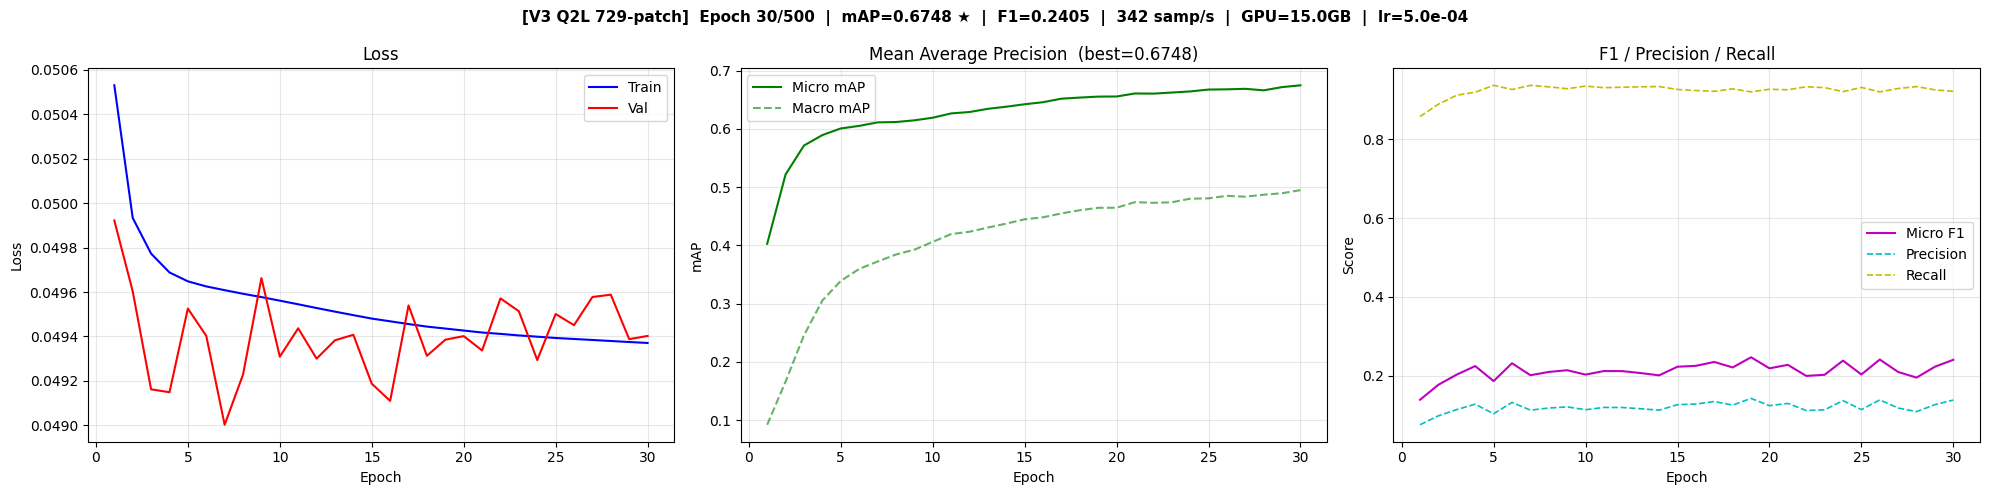

In [ ]:
history = {k: [] for k in [
    "train_loss", "val_loss", "mAP", "macro_mAP",
    "micro_f1", "macro_f1", "micro_precision", "micro_recall",
    "lr", "gpu_mem_gb", "epoch_time",
]}
best_map = 0.0
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plt.ion()

for epoch in range(1, cfg.epochs + 1):
    t0 = time.time()
    rfs.set_epoch(epoch)

    train_loss  = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device)
    val_metrics = evaluate(model, val_loader, criterion, device, cfg.eval_threshold)

    elapsed = time.time() - t0
    gpu_mem = torch.cuda.max_memory_allocated() / 1024**3 if device == "cuda" else 0
    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()

    current_lr = optimizer.param_groups[0]["lr"]
    for k, v in [("train_loss", train_loss), ("val_loss", val_metrics["loss"]),
                 ("mAP", val_metrics["mAP"]), ("macro_mAP", val_metrics["macro_mAP"]),
                 ("micro_f1", val_metrics["micro_f1"]), ("macro_f1", val_metrics["macro_f1"]),
                 ("micro_precision", val_metrics["micro_precision"]),
                 ("micro_recall", val_metrics["micro_recall"]),
                 ("lr", current_lr), ("gpu_mem_gb", gpu_mem), ("epoch_time", elapsed)]:
        history[k].append(v)

    if val_metrics["mAP"] > best_map:
        best_map = val_metrics["mAP"]
        torch.save({
            "epoch": epoch, "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "mAP": best_map, "config": cfg, "version": "v3",
        }, best_path)

    clear_output(wait=True)
    for ax in axes: ax.clear()
    ex = range(1, epoch + 1)

    axes[0].plot(ex, history["train_loss"], "b-", label="Train", linewidth=1.5)
    axes[0].plot(ex, history["val_loss"],   "r-", label="Val",   linewidth=1.5)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ex, history["mAP"],       "g-",  label="Micro mAP", linewidth=1.5)
    axes[1].plot(ex, history["macro_mAP"], "g--", label="Macro mAP", linewidth=1.5, alpha=0.6)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("mAP")
    axes[1].set_title(f"Mean Average Precision  (best={best_map:.4f})")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(ex, history["micro_f1"],       "m-",  label="Micro F1",  linewidth=1.5)
    axes[2].plot(ex, history["micro_precision"], "c--", label="Precision", linewidth=1.2)
    axes[2].plot(ex, history["micro_recall"],    "y--", label="Recall",    linewidth=1.2)
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Score")
    axes[2].set_title("F1 / Precision / Recall")
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    is_best = " ★" if val_metrics["mAP"] >= best_map else ""
    fig.suptitle(
        f"[V3 Q2L 729-patch]  Epoch {epoch}/{cfg.epochs}  |  "
        f"mAP={val_metrics['mAP']:.4f}{is_best}  |  "
        f"F1={val_metrics['micro_f1']:.4f}  |  "
        f"{len(rfs)/elapsed:.0f} samp/s  |  "
        f"GPU={gpu_mem:.1f}GB  |  lr={current_lr:.1e}",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout(); display(fig)

    if early_stopping(val_metrics["mAP"], epoch):
        print(f"\nEarly stopping at epoch {epoch}. "
              f"Best mAP={best_map:.4f} at epoch {early_stopping.best_epoch}")
        break

plt.ioff()
avg_time = np.mean(history["epoch_time"])
print(f"\n{'='*60}")
print(f"  V3 Training complete")
print(f"{'='*60}")
print(f"  Best mAP       : {best_map:.4f}")
print(f"  Avg epoch time : {avg_time:.1f}s")
print(f"  Peak GPU mem   : {max(history['gpu_mem_gb']):.1f} GB")
print(f"  Checkpoint     : {best_path}")

---
## 8. Evaluation — Per-class AP Analysis

In [ ]:
from sklearn.metrics import average_precision_score

checkpoint = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded best_model_v3.pt — epoch {checkpoint['epoch']}, mAP={checkpoint['mAP']:.4f}")

model.eval()
all_logits, all_targets = [], []
with torch.no_grad():
    for patches, target in val_loader:
        all_logits.append(model(patches.to(device)).cpu())
        all_targets.append(target)

all_logits  = torch.cat(all_logits)
all_targets = torch.cat(all_targets)
all_probs   = torch.sigmoid(all_logits).numpy()
all_tgts_np = all_targets.numpy()

has_pos = all_tgts_np.sum(axis=0) > 0
per_class_ap = np.zeros(vocab.size)
for i in range(vocab.size):
    if has_pos[i]:
        per_class_ap[i] = average_precision_score(all_tgts_np[:, i], all_probs[:, i])

sorted_idx = np.argsort(per_class_ap)[::-1]

print(f"\n{'='*65}")
print(f"  TOP 20  (by AP)")
print(f"{'='*65}")
print(f"  {'Rank':>4}  {'Label':>22}  {'AP':>8}  {'Support':>8}")
for rank, idx in enumerate(sorted_idx[:20]):
    print(f"  {rank+1:4d}  {vocab.idx_to_label[idx]:>22s}  "
          f"{per_class_ap[idx]:8.4f}  {int(all_tgts_np[:, idx].sum()):8d}")

print(f"\n{'='*65}")
print(f"  BOTTOM 20  (support > 0)")
print(f"{'='*65}")
for rank, idx in enumerate([i for i in sorted_idx[::-1] if has_pos[i]][:20]):
    print(f"  {rank+1:4d}  {vocab.idx_to_label[idx]:>22s}  "
          f"{per_class_ap[idx]:8.4f}  {int(all_tgts_np[:, idx].sum()):8d}")

valid_aps = per_class_ap[has_pos]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(valid_aps, bins=50, color="steelblue", edgecolor="white")
ax.axvline(valid_aps.mean(), color="red", linestyle="--",
           label=f"Mean AP = {valid_aps.mean():.3f}")
ax.set_xlabel("Average Precision")
ax.set_ylabel("Number of classes")
ax.set_title("V3 — Per-Class AP Distribution (Q2L + 729 patches)")
ax.legend(); plt.tight_layout(); plt.show()

---
## 9. Inference Demo — Prediction Visualization

In [ ]:
import json
from PIL import Image
from matplotlib.patches import Patch
from node_extractor_from_latent.utils import normalize_label

with open(cfg.val_jsonl) as f:
    val_lines = f.readlines()

NUM_VIS = 4
random.seed(42)
vis_indices = random.sample(range(len(val_lines)), NUM_VIS)

model.eval()

for sample_idx in vis_indices:
    entry          = json.loads(val_lines[sample_idx])
    gt_labels_raw  = [node["label"] for node in entry["groundTruth"]["nodes"]]
    gt_labels_norm = set(normalize_label(l) for l in gt_labels_raw)

    patches_emb, _ = val_ds[sample_idx]
    with torch.no_grad():
        probs = torch.sigmoid(
            model(patches_emb.unsqueeze(0).to(device))
        ).squeeze(0).cpu()

    top_k = 25
    top_scores, top_idx = torch.topk(probs, top_k)
    pred_labels = [vocab.idx_to_label[i.item()] for i in top_idx]
    pred_scores = top_scores.tolist()
    pred_hits   = [label in gt_labels_norm for label in pred_labels]

    all_preds = vocab.decode(probs, threshold=cfg.eval_threshold)
    pred_set  = set(l for l, _ in all_preds)
    tp        = len(pred_set & gt_labels_norm)
    precision = tp / len(pred_set)       if pred_set        else 0
    recall    = tp / len(gt_labels_norm) if gt_labels_norm  else 0
    f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0

    fig = plt.figure(figsize=(18, 7))
    gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1.4], wspace=0.05)

    ax_img = fig.add_subplot(gs[0])
    if entry.get("image_path") and Path(entry["image_path"]).exists():
        ax_img.imshow(Image.open(entry["image_path"]))
    else:
        ax_img.text(0.5, 0.5, "Image not available", ha="center", va="center",
                    fontsize=14, transform=ax_img.transAxes)
    ax_img.set_title(
        f"{entry['id']}  ({entry['metadata']['source'].upper()})\n"
        f"GT: {len(gt_labels_norm)} entities  |  Pred: {len(all_preds)} above {cfg.eval_threshold}",
        fontsize=11, fontweight="bold", pad=10,
    )
    ax_img.axis("off")
    gt_text = ", ".join(sorted(gt_labels_norm)[:20])
    if len(gt_labels_norm) > 20:
        gt_text += f"  (+{len(gt_labels_norm)-20} more)"
    ax_img.text(
        0.5, -0.02, f"Ground Truth: {gt_text}",
        ha="center", va="top", fontsize=8, color="#444",
        transform=ax_img.transAxes, wrap=True,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="#ccc"),
    )

    ax_bar = fig.add_subplot(gs[1])
    y_pos  = np.arange(top_k)[::-1]
    colors = ["#2ecc71" if h else "#e74c3c" for h in pred_hits]
    ax_bar.barh(y_pos, pred_scores, color=colors,
                edgecolor=["#27ae60" if h else "#c0392b" for h in pred_hits], height=0.7)
    ax_bar.axvline(cfg.eval_threshold, color="#555", linestyle="--", linewidth=1, alpha=0.7)
    ax_bar.text(cfg.eval_threshold+0.01, top_k-0.5,
                f"threshold={cfg.eval_threshold}", fontsize=8, color="#555", va="bottom")

    for i, (label, score, hit) in enumerate(zip(pred_labels, pred_scores, pred_hits)):
        marker = "\u2713" if hit else "\u2717"
        ax_bar.text(0.01, y_pos[i], f"  {marker} {label}", va="center", ha="left",
                    fontsize=9, fontweight="bold" if hit else "normal",
                    color="white" if score > 0.3 else "#333")
        ax_bar.text(score+0.008, y_pos[i], f"{score:.3f}",
                    va="center", ha="left", fontsize=8, color="#333")

    ax_bar.set_xlim(0, 1.05); ax_bar.set_yticks([])
    ax_bar.set_xlabel("Confidence Score", fontsize=10)
    ax_bar.set_title(
        f"Top {top_k} Predictions  [V3 Q2L 729-patch]  |  "
        f"P={precision:.2f}  R={recall:.2f}  F1={f1:.2f}",
        fontsize=11, fontweight="bold", pad=10,
    )
    for spine in ["top", "right", "left"]:
        ax_bar.spines[spine].set_visible(False)
    ax_bar.legend(
        handles=[Patch(facecolor="#2ecc71", label="In ground truth"),
                 Patch(facecolor="#e74c3c", label="Not in ground truth")],
        loc="lower right", fontsize=9, framealpha=0.9,
    )
    plt.tight_layout(); plt.show(); print()